# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

RESPONSE:
One notable trend I have identified is that applicant age appears to have a significant impact on loan approval decisions, whereas education level seems to have little to no effect. Unfortunately, individuals over the age of 61 are consistently denied loans, even when their applications demonstrate strong qualification, such as high level of education, substantial income, excellent credit scores, long credit histories, and no prior defaults. Based on these findings, it is my "Professional" opinion that this financial institution should prepare for a lawsuit due to age-based discrimination.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


In [4]:
df.loc[df['person_age'] <= 35, 'Age_cat'] = 0
df.loc[(df['person_age'] <= 65) & (df['person_age'] > 35), 'Age_cat'] = 1
df.loc[df['person_age'] > 65, 'Age_cat'] = 2

pd.crosstab(df['person_age'], df['Age_cat'])


Age_cat,0.0,1.0,2.0
person_age,,,
20,669,0,0
21,695,0,0
22,690,0,0
23,693,0,0
24,690,0,0
...,...,...,...
81,0,0,696
82,0,0,738
83,0,0,636


In [5]:
pd.crosstab(df['Age_cat'], df['loan_status'])

loan_status,0,1
Age_cat,,
0.0,9021,1961
1.0,17410,2932
2.0,13676,0


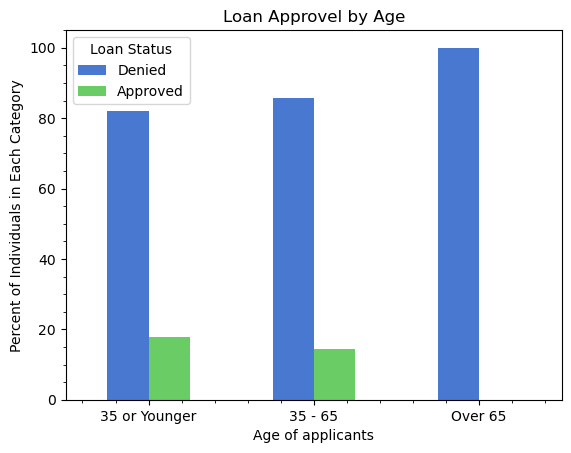

In [6]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted')
parch_crosstab = pd.crosstab(df['Age_cat'], df['loan_status'], normalize='index')*100

parch_crosstab.plot(kind='bar')

plt.title('Loan Approvel by Age')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2]
x_labels = ['35 or Younger','35 - 65', 'Over 65']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()

plt.xlabel('Age of applicants')

plt.legend(['Denied', 'Approved'], title='Loan Status')

plt.show()

In [7]:
pd.crosstab(df['person_gender'] , df['loan_status'])

loan_status,0,1
person_gender,,
female,15934,1975
male,24173,2918


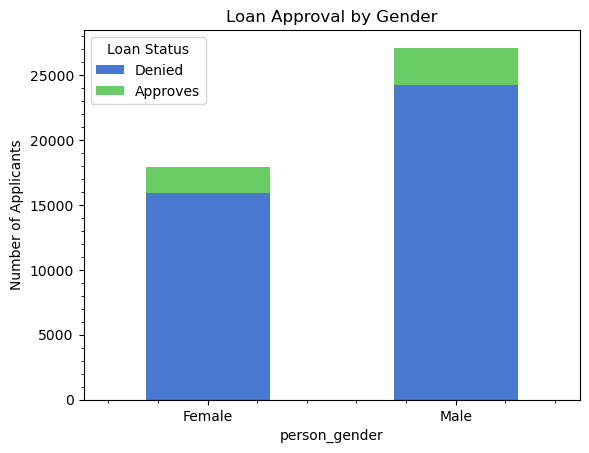

In [8]:
pd.crosstab(df['person_gender'] , df['loan_status']).plot(kind='bar', stacked=True)

plt.title('Loan Approval by Gender')
plt.ylabel('Number of Applicants')

plt.legend(['Denied', 'Approves'], title='Loan Status')
plt.minorticks_on()
current_position =[0,1]

x_labels = ["Female" , "Male"]

plt.xticks(current_position, x_labels, rotation=0)


plt.show()

In [9]:
df['person_income'].describe()
            

count     45000.000000
mean      60158.033820
std       19849.803913
min       10000.000000
25%       46649.073063
50%       60200.760251
75%       73452.873880
max      141514.800793
Name: person_income, dtype: float64

In [10]:
q25 = df['person_income'].quantile(0.25) 
q50 = df['person_income'].quantile(0.50) 
q75 = df['person_income'].quantile(0.75) 

df.loc[df['person_income'] <= q25, 'income_cat'] = 0
df.loc[(df['person_income'] <= q50) & (df['person_income'] > q25), 'income_cat'] = 1
df.loc[(df['person_income'] > q50) & (df['person_income'] < q75), 'income_cat'] = 2
df.loc[df['person_income'] >= q75, 'income_cat'] = 3

pd.crosstab(df['person_income'], df['income_cat'])

income_cat,0.0,1.0,2.0,3.0
person_income,,,,
10000.000000,291,0,0,0
10003.739002,1,0,0,0
10004.707510,1,0,0,0
10014.804842,1,0,0,0
10029.142836,1,0,0,0
...,...,...,...,...
135439.410163,0,0,0,1
136424.119467,0,0,0,1
136654.458842,0,0,0,1


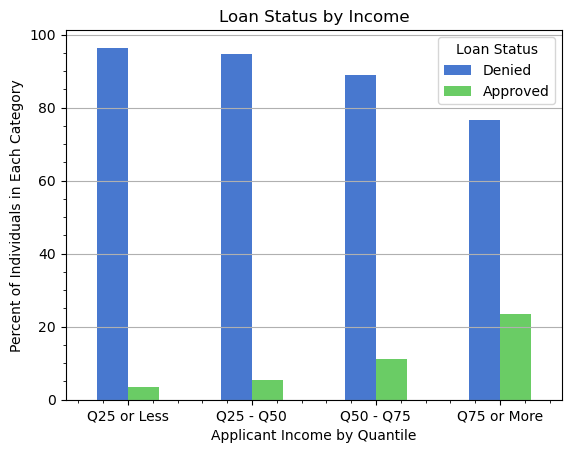

In [11]:
income_crosstab = pd.crosstab(df['income_cat'], df['loan_status'], normalize='index')*100

income_crosstab.plot(kind='bar')

plt.title('Loan Status by Income')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2,3]
x_labels = ['Q25 or Less','Q25 - Q50', 'Q50 - Q75', 'Q75 or More']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()
plt.grid(axis='y')

plt.xlabel('Applicant Income by Quantile')

plt.legend(['Denied', 'Approved'], title='Loan Status')

plt.show()


In [12]:
df['credit_score'].describe()

count    45000.000000
mean       679.850140
std         69.875265
min        395.607228
25%        632.541710
50%        680.044374
75%        727.660232
max        850.000000
Name: credit_score, dtype: float64

In [13]:
q25 = df['credit_score'].quantile(0.25) 
q50 = df['credit_score'].quantile(0.50) 
q75 = df['credit_score'].quantile(0.75) 

df.loc[df['credit_score'] <= q25, 'credit_cat'] = 0
df.loc[(df['credit_score'] <= q50) & (df['credit_score'] > q25), 'credit_cat'] = 1
df.loc[(df['credit_score'] > q50) & (df['credit_score'] < q75), 'credit_cat'] = 2
df.loc[df['credit_score'] >= q75, 'credit_cat'] = 3

pd.crosstab(df['credit_score'], df['credit_cat'])

credit_cat,0.0,1.0,2.0,3.0
credit_score,,,,
395.607228,1,0,0,0
420.115825,1,0,0,0
425.180413,1,0,0,0
428.214778,1,0,0,0
428.835333,1,0,0,0
...,...,...,...,...
849.819436,0,0,0,1
849.966259,0,0,0,1
849.973109,0,0,0,1


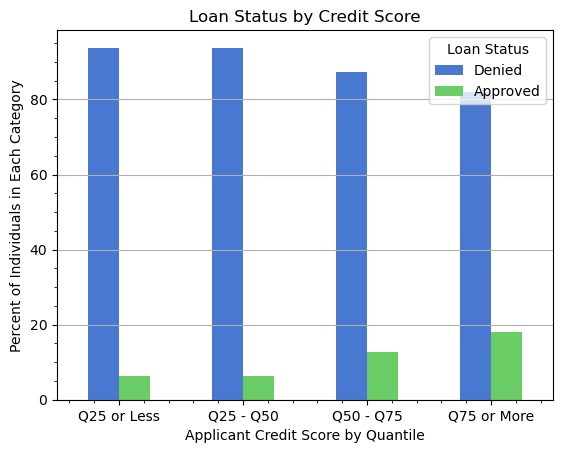

In [14]:
credit_crosstab = pd.crosstab(df['credit_cat'], df['loan_status'], normalize='index')*100

credit_crosstab.plot(kind='bar')

plt.title('Loan Status by Credit Score')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2,3]
x_labels = ['Q25 or Less','Q25 - Q50', 'Q50 - Q75', 'Q75 or More']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()
plt.grid(axis='y')

plt.xlabel('Applicant Credit Score by Quantile')

plt.legend(['Denied', 'Approved'], title='Loan Status')

plt.show()

In [15]:
df['cb_person_cred_hist_length'].describe()

count    45000.000000
mean        15.025178
std          8.382003
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         29.000000
Name: cb_person_cred_hist_length, dtype: float64

In [16]:
q25 = df['cb_person_cred_hist_length'].quantile(0.25) 
q50 = df['cb_person_cred_hist_length'].quantile(0.50) 
q75 = df['cb_person_cred_hist_length'].quantile(0.75) 

df.loc[df['cb_person_cred_hist_length'] <= q25, 'his_cat'] = 0
df.loc[(df['cb_person_cred_hist_length'] <= q50) & (df['cb_person_cred_hist_length'] > q25), 'his_cat'] = 1
df.loc[(df['cb_person_cred_hist_length'] > q50) & (df['cb_person_cred_hist_length'] < q75), 'his_cat'] = 2
df.loc[df['cb_person_cred_hist_length'] >= q75, 'his_cat'] = 3

pd.crosstab(df['cb_person_cred_hist_length'], df['his_cat'])

his_cat,0.0,1.0,2.0,3.0
cb_person_cred_hist_length,,,,
1,1535,0,0,0
2,1573,0,0,0
3,1517,0,0,0
4,1595,0,0,0
5,1597,0,0,0
6,1508,0,0,0
7,1499,0,0,0
8,1584,0,0,0
9,0,1492,0,0


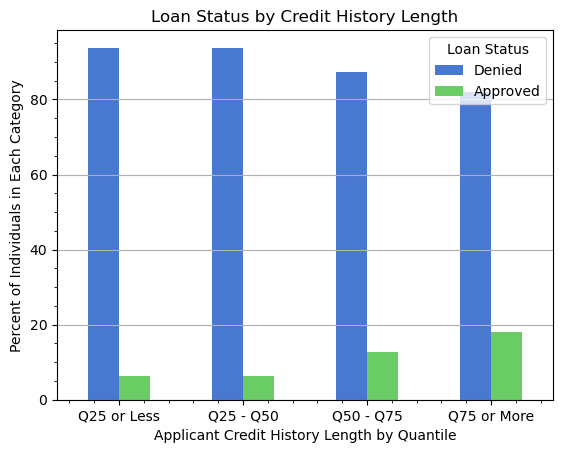

In [17]:
his_crosstab = pd.crosstab(df['credit_cat'], df['loan_status'], normalize='index')*100

his_crosstab.plot(kind='bar')

plt.title('Loan Status by Credit History Length')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2,3]
x_labels = ['Q25 or Less','Q25 - Q50', 'Q50 - Q75', 'Q75 or More']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()
plt.grid(axis='y')

plt.xlabel('Applicant Credit History Length by Quantile')

plt.legend(['Denied', 'Approved'], title='Loan Status')

plt.show()

In [18]:
pd.crosstab(df['previous_loan_defaults_on_file'] , df['loan_status'])	

loan_status,0,1
previous_loan_defaults_on_file,,
No,35556,4893
Yes,4551,0


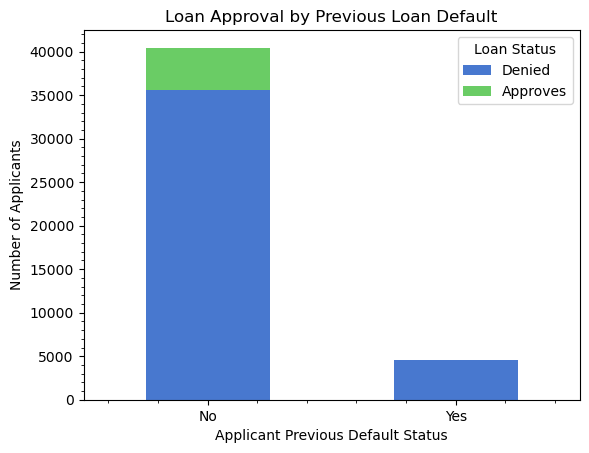

In [19]:
pd.crosstab(df['previous_loan_defaults_on_file'] , df['loan_status']).plot(kind='bar', stacked=True)

plt.title('Loan Approval by Previous Loan Default')
plt.ylabel('Number of Applicants')

plt.legend(['Denied', 'Approves'], title='Loan Status')
plt.xlabel('Applicant Previous Default Status')

current_position =[0,1]
x_labels = ['No', 'Yes']
plt.minorticks_on()
plt.xticks(current_position, x_labels, rotation=0)

plt.show()

In [20]:
pd.crosstab(df['person_education'] , df['loan_status'])	


loan_status,0,1
person_education,,
Associate,8016,922
Bachelor,7963,988
Doctorate,8068,992
High School,8112,990
Master,7948,1001


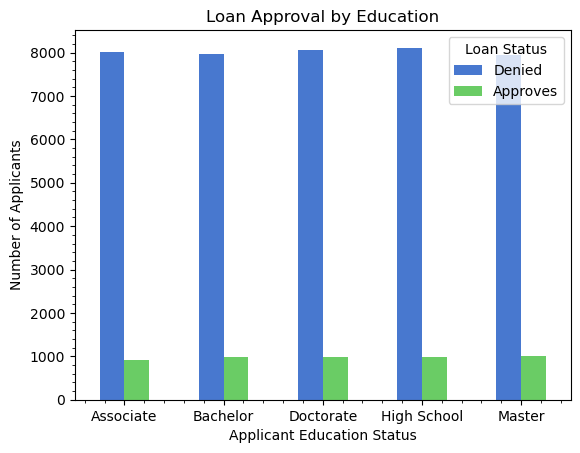

In [24]:
pd.crosstab(df['person_education'] , df['loan_status']).plot(kind='bar')

plt.title('Loan Approval by Education')
plt.ylabel('Number of Applicants')

plt.legend(['Denied', 'Approves'], title='Loan Status')
plt.xlabel('Applicant Education Status')

current_position =[0,1,2,3,4]
x_labels = ['Associate', 'Bachelor', 'Doctorate', 'High School', 'Master']
plt.minorticks_on()
plt.xticks(current_position, x_labels, rotation=0)

plt.show()

In [25]:
df['loan_amnt'].describe()

count    45000.000000
mean     15129.737112
std       7727.944812
min       1000.000000
25%       9619.848951
50%      14999.516858
75%      20371.680125
max      49894.641004
Name: loan_amnt, dtype: float64

In [26]:
q25 = df['loan_amnt'].quantile(0.25) 
q50 = df['loan_amnt'].quantile(0.50) 
q75 = df['loan_amnt'].quantile(0.75) 

df.loc[df['loan_amnt'] <= q25, 'his_cat'] = 0
df.loc[(df['loan_amnt'] <= q50) & (df['loan_amnt'] > q25), 'loan_cat'] = 1
df.loc[(df['loan_amnt'] > q50) & (df['loan_amnt'] < q75), 'loan_cat'] = 2
df.loc[df['loan_amnt'] >= q75, 'loan_cat'] = 3

pd.crosstab(df['loan_amnt'], df['loan_cat'])

loan_cat,1.0,2.0,3.0
loan_amnt,,,
9620.003336,1,0,0
9620.162884,1,0,0
9620.172428,1,0,0
9620.353029,1,0,0
9620.891511,1,0,0
...,...,...,...
45705.896352,0,0,1
45944.075437,0,0,1
48082.555149,0,0,1


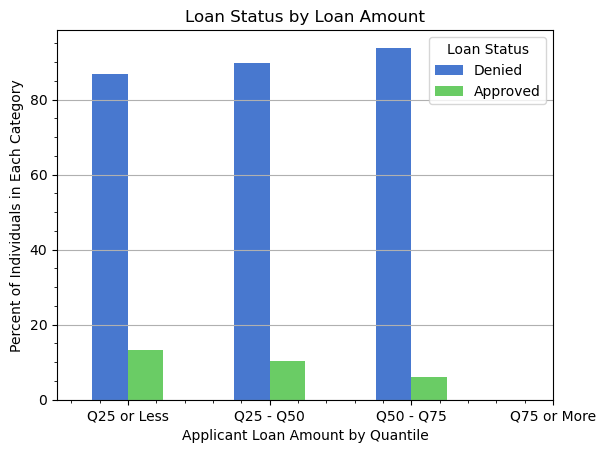

In [50]:
his_crosstab = pd.crosstab(df['loan_cat'], df['loan_status'], normalize='index')*100

his_crosstab.plot(kind='bar')

plt.title('Loan Status by Loan Amount')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2,3]
x_labels = ['Q25 or Less','Q25 - Q50', 'Q50 - Q75', 'Q75 or More']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()
plt.grid(axis='y')

plt.xlabel('Applicant Loan Amount by Quantile')

plt.legend(['Denied', 'Approved'], title='Loan Status')

plt.show()

In [48]:
sur_df = df [(df['person_age'] >= 61) & (df['loan_amnt'] <= df['loan_amnt'].quantile(0.25)) & (df['previous_loan_defaults_on_file'] == 'No') &
(df['cb_person_cred_hist_length'] >= df['cb_person_cred_hist_length'].quantile(0.75)) & (df['credit_score'] >= df['credit_score'].quantile(0.75)) &  (df['person_income'] >= df['person_income'].quantile(0.75))
& (df['loan_status'] == 0)]
sur_df.head(100)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,Age_cat,income_cat,credit_cat,his_cat,loan_cat
995,76,male,Associate,83496.855950,26,MORTGAGE,7965.930454,EDUCATION,11.242332,0.095404,24,796.700437,No,0,2.0,3.0,3.0,0.0,NaN
1236,65,male,Bachelor,79098.945337,3,OWN,3059.272247,VENTURE,9.636809,0.038677,23,756.439782,No,0,1.0,3.0,3.0,0.0,NaN
2233,65,female,High School,101143.787218,26,RENT,1598.333265,HOMEIMPROVEMENT,8.542286,0.015803,25,821.874504,No,0,1.0,3.0,3.0,0.0,NaN
2273,77,female,High School,82570.459012,8,RENT,5368.142007,PERSONAL,10.965467,0.065013,29,776.761675,No,0,2.0,3.0,3.0,0.0,NaN
3146,81,male,Associate,90619.951692,16,MORTGAGE,9392.982954,HOMEIMPROVEMENT,11.780360,0.103652,23,777.013196,No,0,2.0,3.0,3.0,0.0,NaN
3428,68,male,Bachelor,83535.302989,24,RENT,5647.641031,MEDICAL,10.528555,0.067608,28,778.597201,No,0,2.0,3.0,3.0,0.0,NaN
3486,81,male,High School,81142.002607,4,MORTGAGE,3183.245132,MEDICAL,16.560352,0.039231,23,747.871922,No,0,2.0,3.0,3.0,0.0,NaN
4532,61,male,Bachelor,80743.371647,18,RENT,5338.244566,HOMEIMPROVEMENT,20.423090,0.066114,23,730.104865,No,0,1.0,3.0,3.0,0.0,NaN
4558,85,male,High School,85903.440122,20,OWN,9358.183378,HOMEIMPROVEMENT,10.301350,0.108938,29,744.780362,No,0,2.0,3.0,3.0,0.0,NaN
4654,64,female,Master,85394.173364,11,OWN,7028.935270,DEBTCONSOLIDATION,14.384584,0.082312,22,741.687299,No,0,1.0,3.0,3.0,0.0,NaN
